###Temperature Trend Analysis
This graph shows the overall increase in global temperature over the last 50 years. 
The rolling average smooths short-term fluctuations, while the trend line highlights the long-term upward trend.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [145]:
temp_df = pd.read_csv("GlobalTemperatures.csv")

In [146]:
temp_df['dt'] = pd.to_datetime(temp_df['dt'])
temp_df['Year'] = temp_df['dt'].dt.year
temp_df['Month'] = temp_df['dt'].dt.month


In [147]:
temp_df = temp_df[['Year', 'dt', 'LandAverageTemperature']]
temp_df['Month_Name'] = temp_df['dt'].dt.strftime('%b')
temp_df = temp_df.dropna()

In [148]:
yearly_temp = temp_df.groupby('Year')['LandAverageTemperature'].mean()

In [149]:
yearly_temp = yearly_temp[yearly_temp.index >= 1970]
print(yearly_temp.head())

Year
1970    8.700917
1971    8.599250
1972    8.499583
1973    8.948250
1974    8.467500
Name: LandAverageTemperature, dtype: float64


In [150]:
rolling_temp = yearly_temp.rolling(window=5).mean()

In [151]:
x = yearly_temp.index
y = yearly_temp.values

z = np.polyfit(x, y, 1)
trend_line = np.poly1d(z)


In [152]:
heatmap_data = temp_df.pivot_table(
    values='LandAverageTemperature',
    index='Year',
    columns='Month_Name',
    aggfunc='mean'
)

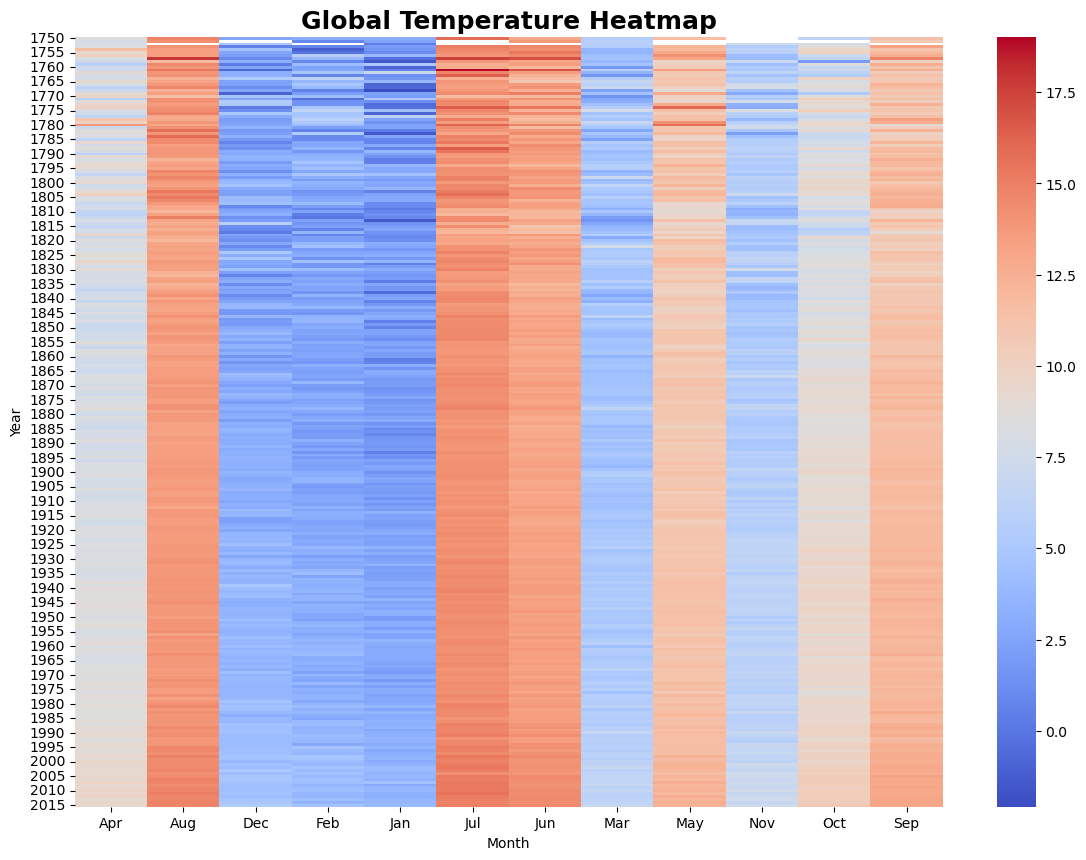

In [153]:
plt.figure(figsize=(14,10))

sns.heatmap(
    heatmap_data,
    cmap='coolwarm'
)

plt.title(
    "Global Temperature Heatmap",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Month")
plt.ylabel("Year")

plt.show()

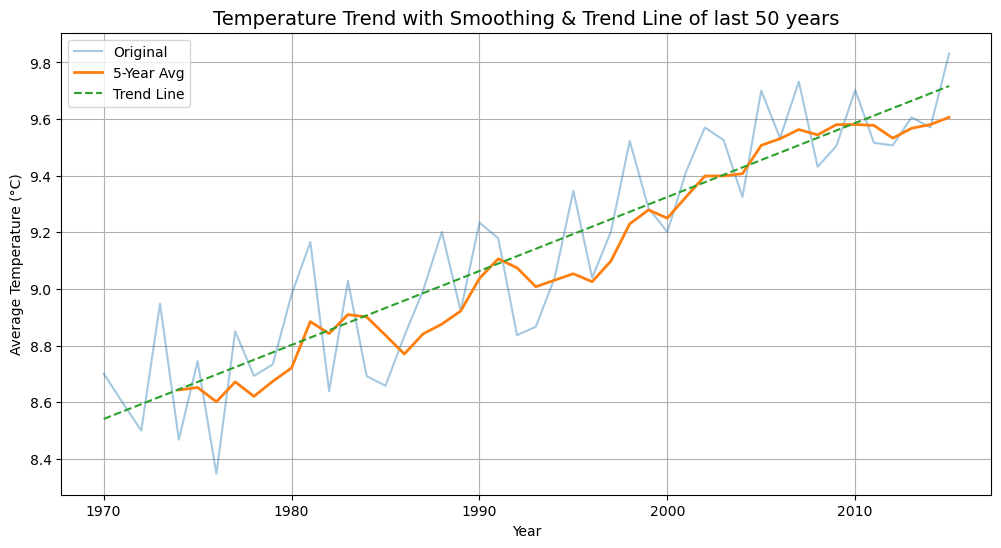

In [154]:
plt.figure(figsize=(12,6))

plt.plot(yearly_temp.index, yearly_temp.values, label='Original', alpha=0.4)
plt.plot(rolling_temp.index, rolling_temp.values, label='5-Year Avg', linewidth=2)
plt.plot(x, trend_line(x), label='Trend Line', linestyle='--')

plt.title("Temperature Trend with Smoothing & Trend Line of last 50 years", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.legend()

plt.grid(True)

plt.show()

In [ ]:
hottest_year = yearly_temp.idxmax()
hottest_value = yearly_temp.max()
print("Hottest Year:", hottest_year)
print("Temperature:", hottest_value)

Hottest Year: 2015
Temperature: 9.831


In [ ]:
coldest_year = yearly_temp.idxmin()
coldest_value = yearly_temp.min()
print("Coldest Year:", coldest_year)

Coldest Year: 1976


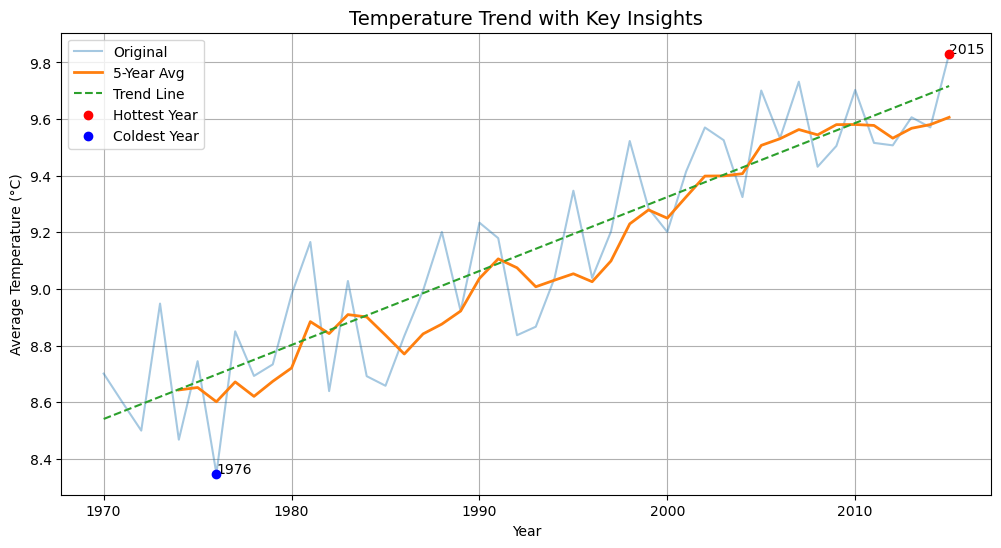

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(yearly_temp.index, yearly_temp.values, label='Original', alpha=0.4)
plt.plot(rolling_temp.index, rolling_temp.values, label='5-Year Avg', linewidth=2)
plt.plot(x, trend_line(x), label='Trend Line', linestyle='--')

# Hottest year 
plt.scatter(hottest_year, hottest_value, color='red', label='Hottest Year', zorder=5)
plt.text(hottest_year, hottest_value, f"{hottest_year}", fontsize=10)

# Coldest year 
plt.scatter(coldest_year, coldest_value, color='blue', label='Coldest Year', zorder=5)
plt.text(coldest_year, coldest_value, f"{coldest_year}", fontsize=10)

plt.title("Temperature Trend with Key Insights", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()


#Key Observations
# - The overall temperature shows an increasing trend over the last 50 years.
# - The rolling average highlights a steady rise in global temperature.
# - The hottest year recorded is 2015(i think its my hotness)
# - (why cant we have one now agh).
# - This suggests a clear indication of global warming trends.